# **Retrieve data from the CSV files** 
#### all tables concecated into one dataframe, calculate the mean per month and put it into one csv file called: mean_no2_monthlyvalues.csv


In [4]:
import pandas as pd
import numpy as np

urls = [
    'https://data.rivm.nl/data/luchtmeetnet/Vastgesteld-jaar/1990/', 
    'https://data.rivm.nl/data/luchtmeetnet/Vastgesteld-jaar/2016/',
    'https://data.rivm.nl/data/luchtmeetnet/Vastgesteld-jaar/2017/',
    'https://data.rivm.nl/data/luchtmeetnet/Vastgesteld-jaar/2018/',
    'https://data.rivm.nl/data/luchtmeetnet/Vastgesteld-jaar/2019/',
    'https://data.rivm.nl/data/luchtmeetnet/Vastgesteld-jaar/2020/',
    'https://data.rivm.nl/data/luchtmeetnet/Vastgesteld-jaar/2021/',
    'https://data.rivm.nl/data/luchtmeetnet/Vastgesteld-jaar/2022/',
    'https://data.rivm.nl/data/luchtmeetnet/Vastgesteld-jaar/2023/',
    'https://data.rivm.nl/data/luchtmeetnet/Vastgesteld-jaar/2024/',
]
csv_suffix = '_NO2.csv' 
all_dfs = [] 


for base_url in urls:
    
    year = base_url.split('/')[-2]
    file_name = year + csv_suffix
    full_url = base_url + file_name 
    
   
    temp_df = pd.read_csv(
        full_url, 
        sep=';', 
        skiprows=5 
    )
    
    all_dfs.append(temp_df)
    print(f"loaded: {file_name}")

#Combine data into one df
main_df = pd.concat(all_dfs, ignore_index=True)

print(f"Total instances: {len(main_df)}")


loaded: 1990_NO2.csv
loaded: 2016_NO2.csv
loaded: 2017_NO2.csv
loaded: 2018_NO2.csv
loaded: 2019_NO2.csv
loaded: 2020_NO2.csv
loaded: 2021_NO2.csv
loaded: 2022_NO2.csv
loaded: 2023_NO2.csv
loaded: 2024_NO2.csv
Total instances: 6666197


In [ ]:
import pandas as pd 
for x in main_df.columns:
    num_unique_values = main_df[x].nunique()
    print(f"Column '{x}' has {num_unique_values} unique values.")

#Unique location IDs for province mapping
sorted_unique_values = main_df['meetlocatie_id'].unique()
sorted_unique_values.sort()
print()
print("Sorted Unique meetreeks IDs:")
print(sorted_unique_values)


Column 'meetreeks_id' has 114 unique values.
Column 'meetlocatie_id' has 114 unique values.
Column 'bron_id' has 7 unique values.
Column 'accreditatienummer' has 4 unique values.
Column 'component' has 1 unique values.
Column 'matrix' has 1 unique values.
Column 'meetopstelling_id' has 6 unique values.
Column 'meetduur' has 1 unique values.
Column 'eenheid' has 1 unique values.
Column 'begindatumtijd' has 87672 unique values.
Column 'einddatumtijd' has 87672 unique values.
Column 'waarde' has 37623 unique values.
Column 'opm_code' has 0 unique values.

Sorted Unique meetreeks IDs:
['NL01483' 'NL01485' 'NL01486' 'NL01487' 'NL01488' 'NL01489' 'NL01491'
 'NL01493' 'NL01494' 'NL01495' 'NL01496' 'NL01497' 'NL01908' 'NL01912'
 'NL01913' 'NL10107' 'NL10131' 'NL10133' 'NL10136' 'NL10138' 'NL10227'
 'NL10230' 'NL10235' 'NL10236' 'NL10237' 'NL10238' 'NL10240' 'NL10241'
 'NL10246' 'NL10247' 'NL10248' 'NL10301' 'NL10318' 'NL10404' 'NL10418'
 'NL10433' 'NL10435' 'NL10437' 'NL10441' 'NL10442' 'NL104

# The nature and structure of the dataset. 
#### source: https://data.rivm.nl/data/luchtmeetnet/readme.pdf

#### Format of the data:
- The data is Time-Series. It consists of sequential measurements of NO₂ concentration taken at specific dates and times across multiple monitoring stations in the Netherlands.

#### Number of instances:
- The exact number will be determined by code output (len(main_df)). Total amount of records in the combined csv dataset (len(df)): 6.666.197. This amount is excluding the headers in the first 5 rows of every dataset


#### Representativity and bias:
- The data is representative of all measuring statements in the netherlands at all times. Different monitoring networks have been used in order to gather the NO2 values.

#### Data structure:
- The data structure is Tabular. It is also relational in that each measurement belongs to a specific date, time, and location.


In [ ]:
import pandas as pd

data_dict = {
    'Variable Name': [
        'meetreeks',              
        'meetlocatie',            
        'bron_id',                
        'accredidatie',           
        'componenten',            
        'matrix',                 
        'meetopstelling_id',      
        'eenheid',                
        'begindatum',             
        'einddatum',              
        'waarde',                 
        'opm_code'                
    ],
    'Description or Meaning': [
        'identifier for the measurement series. ', 
        'identifier for the sampling location.', 
        'identifier for the source (i.e., the monitoring network)', 
        'accreditation number under which the measurements are carried out by a measuring network.', 
        'pollutant shorthand name, also used as an identifier. ', 
        'the environment which contains the pollutant. ', 
        'identifier for the measuring setup (i.e., the used measurement equipment)', 
        'the measurement duration of the measurements. ', 
        'start date time of the measurement.', 
        'end date time of the measurement.', 
        'measurement value', 
        'identifier for remarks.'
    ],
    'Data Type': [
        'string', 
        'string', 
        'string', 
        'string', 
        'string', 
        'string', 
        'string', 
        'string', 
        'string', 
        'string', 
        'Float64', 
        'string'
    ],
    'Units or Scale': [
        'N/A', 
        'N/A', 
        'N/A', 
        'N/A', 
        'N/A', 
        'N/A', 
        'N/A', 
        'N/A', 
        'YYYY-MM-DD HH:MM:SS', 
        'YYYY-MM-DD HH:MM:SS', 
        'micrograms per cubic meter', 
        'N/A'
    ],
    'Encoding': [
        'N/A', 
        'N/A', 
        'N/A', 
        'N/A', 
        'N/A', 
        'N/A', 
        'N/A', 
        'N/A', 
        'N/A', 
        'N/A', 
        'Int', 
        'N/A'
    ]
}

data_dictionary_df = pd.DataFrame(data_dict)
data_dictionary_df = data_dictionary_df.set_index('Variable Name')

data_dictionary_df

print('NO2 dataset shape: ', main_df.shape)
print(main_df.head())

NO2 dataset shape:  (6666197, 13)
        meetreeks_id meetlocatie_id bron_id accreditatienummer component matrix            meetopstelling_id meetduur eenheid             begindatumtijd              einddatumtijd  waarde  opm_code
0  NL10107_NO2_lucht        NL10107     LML                nvt       NO2  lucht  chemoluminesc_philipsPW9762      uur   µg/m³  1990-01-04T09:00:00+01:00  1990-01-04T10:00:00+01:00      34       NaN
1  NL10107_NO2_lucht        NL10107     LML                nvt       NO2  lucht  chemoluminesc_philipsPW9762      uur   µg/m³  1990-01-04T10:00:00+01:00  1990-01-04T11:00:00+01:00      32       NaN
2  NL10107_NO2_lucht        NL10107     LML                nvt       NO2  lucht  chemoluminesc_philipsPW9762      uur   µg/m³  1990-01-04T11:00:00+01:00  1990-01-04T12:00:00+01:00      34       NaN
3  NL10107_NO2_lucht        NL10107     LML                nvt       NO2  lucht  chemoluminesc_philipsPW9762      uur   µg/m³  1990-01-04T12:00:00+01:00  1990-01-04T13:00:00+

# potential data quality problems


In [ ]:
import pandas as pd

# Stel Pandas display-opties in om alle kolommen en rijen in de output te zien
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)


# no scientific notation
pd.set_option('display.float_format', '{:.0f}'.format)

print(main_df.describe(include='all'))
print(main_df[['waarde']].describe())

nan_count = main_df.isnull().sum()
total_rows = len(main_df)
missing_data = nan_count[nan_count > 0]
missing_data = missing_data.sort_values(ascending=False)

if 'waarde' in missing_data.index:
    waarde_missing_info = missing_data.loc[['waarde']]
    print(waarde_missing_info)
else:
    print("There are no NAN values in the 'waarde' column.")

             meetreeks_id meetlocatie_id  bron_id accreditatienummer component   matrix      meetopstelling_id meetduur  eenheid                       begindatumtijd              einddatumtijd  waarde  opm_code
count             6666197        6666197  6666197            6666197   6666197  6666197                6666197  6666197  6666197                              6666197                    6666197 6666197         0
unique                114            114        7                  4         1        1                      6        1        1                                  NaN                      87672     NaN       NaN
top     NL10418_NO2_lucht        NL10418      LML               L224       NO2    lucht  chemoluminesc_API200E      uur    µg/m³                                  NaN  2016-01-04T19:00:00+01:00     NaN       NaN
freq                86826          86826  3817185            3469181   6666197  6666197                3933487  6666197  6666197                            

In [8]:
main_df.info()

#description of df
print(main_df[['waarde']].describe())
print(main_df['waarde'].median())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6666197 entries, 0 to 6666196
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   meetreeks_id        object 
 1   meetlocatie_id      object 
 2   bron_id             object 
 3   accreditatienummer  object 
 4   component           object 
 5   matrix              object 
 6   meetopstelling_id   object 
 7   meetduur            object 
 8   eenheid             object 
 9   begindatumtijd      object 
 10  einddatumtijd       object 
 11  waarde              float64
 12  opm_code            float64
dtypes: float64(2), object(11)
memory usage: 661.2+ MB
             waarde
count  6.666197e+06
mean   2.097874e+01
std    1.710816e+01
min    1.000000e-02
25%    8.540000e+00
50%    1.600000e+01
75%    2.870000e+01
max    4.350000e+02
16.0


# Analyse the distribution for all relevant variables

In [ ]:
!pip install scipy
!pip install numpy as np
!pip install matplotlib.pyplot as plt



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\enock\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


ERROR: Could not find a version that satisfies the requirement as (from versions: none)
ERROR: No matching distribution found for as

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\enock\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [26]:
#how many series (meetreeks_id) per location
contingency_table = pd.crosstab(
    index=main_df['meetlocatie_id'], 
    columns=main_df['meetreeks_id']
)

# Save to CSV file
contingency_table.to_csv('meetreeks_per_meetlocatie.csv', index=True)
print("Contingency table has been saved as 'meetreeks_per_meetlocatie.csv'")


Contingency table has been saved as 'meetreeks_per_meetlocatie.csv'


6666197 entries, which is correct because there are 6666197 instances.

In [27]:
print("Total entries:", len(main_df['meetreeks_id']))
print("Unique meetreeks_id:", main_df['meetreeks_id'].nunique())
print("Missing values:", main_df['meetreeks_id'].isna().sum())


Total entries: 6666197
Unique meetreeks_id: 114
Missing values: 0


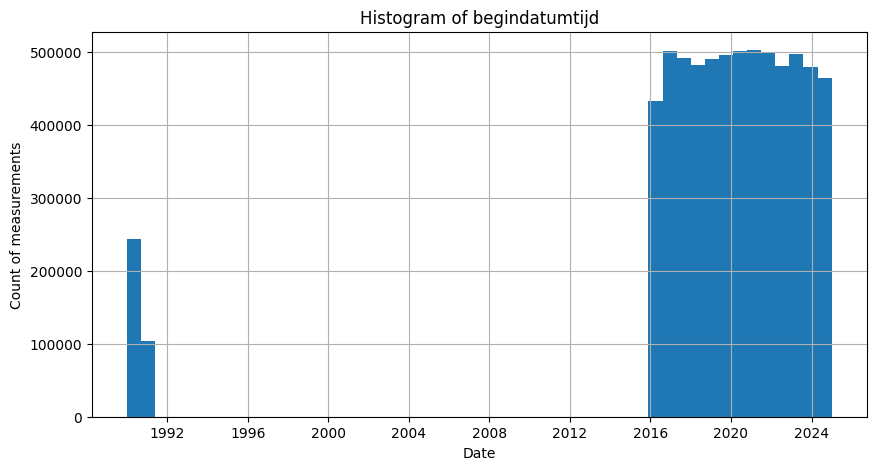

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
main_df['begindatumtijd'] = pd.to_datetime(main_df['begindatumtijd'], errors='coerce')
main_df['begindatumtijd'].diff().describe()
plt.figure(figsize=(10,5))
main_df['begindatumtijd'].hist(bins=50)
plt.title('Histogram of begindatumtijd')
plt.xlabel('Date')
plt.ylabel('Count of measurements')
plt.show()

In [28]:
print("Total entries:", len(main_df['begindatumtijd']))
print("Unique begindatumtijd:", main_df['begindatumtijd'].nunique())
print("Missing values:", main_df['begindatumtijd'].isna().sum())

Total entries: 6666197
Unique begindatumtijd: 87672
Missing values: 0


In [18]:
main_df.duplicated(subset=['begindatumtijd', 'meetreeks_id']).any()


np.False_

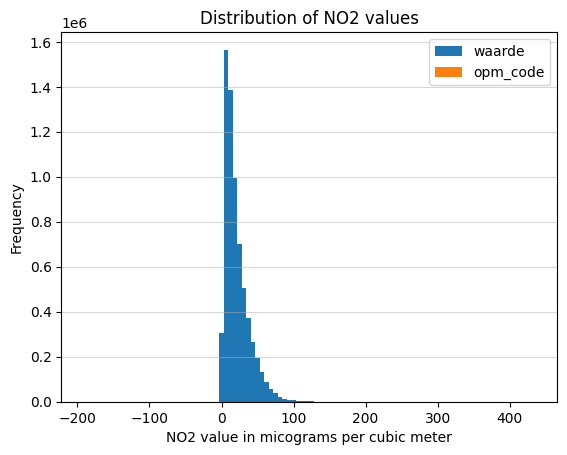

In [ ]:
import pandas as pd
import numpy as np
ax= main_df.plot(
    kind='hist', 
    bins=100, 
    title='Distribution of NO2 values'
)

plt.ylabel("Frequency") 
plt.xlabel("NO2 value in micograms per cubic meter")

plt.show()

## Duplicate instances 

In [ ]:
import pandas as pd
duplicate_count = main_df.duplicated().sum()

if duplicate_count > 0:
    print(f"Found {duplicate_count} instances")
else:
    print("No duplicate instances found.")

No duplicate instances found.


## Outliers
In the beginning of the notebook, a preview of a potential data quality problem was shown. For this project, it is
advised not to remove them

In [ ]:
import pandas as pd

pd.set_option('display.float_format', '{:.4f}'.format)
print(main_df[['waarde']].describe())


            waarde
count 6666197.0000
mean       20.9694
std        17.1157
min      -191.0000
25%         8.5400
50%        16.0000
75%        28.7000
max       435.0000


In [ ]:
import pandas as pd
import numpy as np

#minimum value
min_waarde = main_df['waarde'].min()
min_waarde_frequentie = (main_df['waarde'] == min_waarde).sum()

#maximum value
max_waarde = main_df['waarde'].max()
max_waarde_frequentie = (main_df['waarde'] == max_waarde).sum()

#values less than or equal to 0
# are necessary 
# because they ensure the Boolean operation is completed before the attempts to count the results. 
nonpositive_values = (main_df['waarde'] <= 0).sum()


#minimum and frequencency
print(f"Minimum value in dataset: {min_waarde:.0f}")
print(f"Frequency minimum value: {min_waarde_frequentie}")

#maximum and frequencency
print(f"Maximum value in dataset: {max_waarde:.0f}")
print(f"Frequency of maximum value: {max_waarde_frequentie}")

#non_positive values
print(f"Frequency of No2 values below  or equal to 0: {nonpositive_values}")
print(f'This is {nonpositive_values/len(main_df)*100:.2f}% of the total instances.')

Minimum value in dataset: -191
Frequency minimum value: 1
Maximum value in dataset: 435
Frequency of maximum value: 1
Frequency of No2 values below  or equal to 0: 10908
This is 0.16% of the total instances.


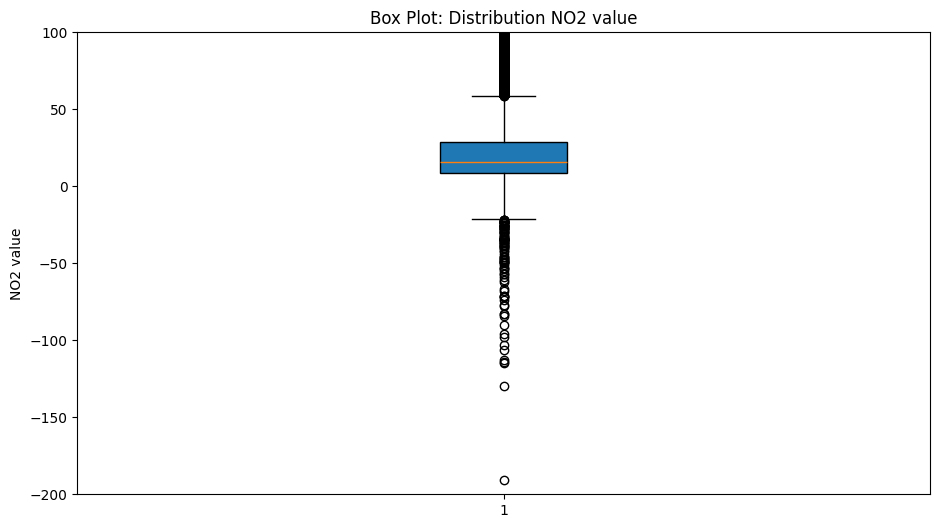

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(11, 6))
plt.boxplot(
    main_df['waarde'], 
    vert=True, 
    patch_artist=True
)

plt.ylim(-200, 100)

plt.title("Box Plot: Distribution NO2 value")
plt.ylabel("NO2 value")
plt.show()

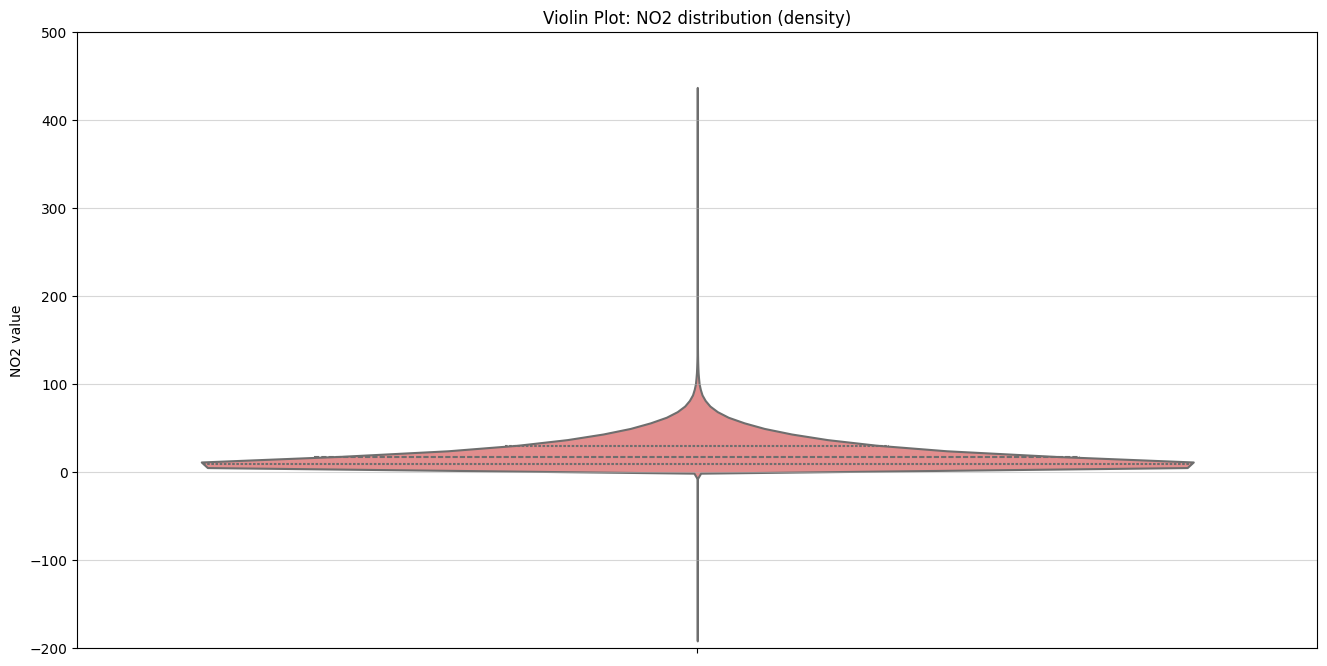

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 8))

sns.violinplot(
    y=main_df['waarde'],
    inner='quartile', 
    color='lightcoral',
    linewidth=1.5
)

plt.ylim(-200, 500) 

plt.title("Violin Plot: NO2 distribution (density)")
plt.ylabel("NO2 value")
plt.grid(True, axis='y', alpha=0.5)
plt.show()

## Seaborn visualisations

In [ ]:
!pip install seaborn



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\enock\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


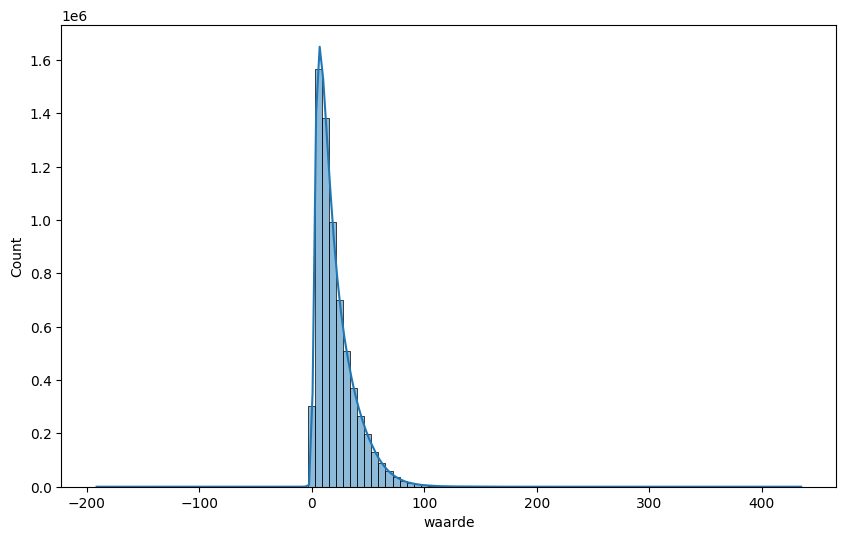

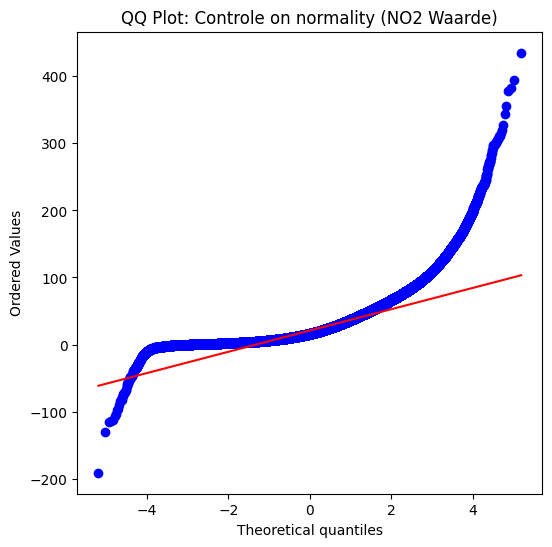

In [ ]:
import scipy.stats as stats
import seaborn as sns 

plt.figure(figsize=(10, 6))
sns.histplot(
    main_df['waarde'], 
    bins=100, 
    kde=True
)
plt.figure(figsize=(6, 6))
stats.probplot(
    main_df['waarde'], 
    dist="norm", 
    plot=plt
)

plt.title("QQ Plot: Controle on normality (NO2 Waarde)")
plt.show()

In [ ]:
print(main_df['waarde'].skew())


1.7106930659101702


# Non positive values

During the process of data collection of historic NO2 values, we came across the following: Many values were below 0, with the lowest value being -191. Most of the “missing” values were in the 1990 dataset, 6000 out of 10908 values equal or below 0. In the code, we call these values NAN values

In [ ]:
import pandas as pd

non_positive_df = main_df[main_df['waarde'] <= 0]

if non_positive_df.empty:
    print("No values found that are 0 or less.")
else:
    # returns a series
    error_counts = non_positive_df['meetreeks_id'].value_counts()
    total_non_positive_values = error_counts.sum()
    print(f"Total amount of non-positive values: {total_non_positive_values}")
    # convert series to dataFrame
    error_table_df = error_counts.reset_index()
    
    print(error_table_df)

Total amount of non-positive values: 10908
          meetreeks_id  count
0    NL10918_NO2_lucht   1112
1    NL10934_NO2_lucht   1059
2    NL10538_NO2_lucht    792
3    NL10301_NO2_lucht    684
4    NL01913_NO2_lucht    537
..                 ...    ...
98   NL10246_NO2_lucht      1
99   NL10641_NO2_lucht      1
100  NL10550_NO2_lucht      1
101  NL10442_NO2_lucht      1
102  NL10241_NO2_lucht      1

[103 rows x 2 columns]


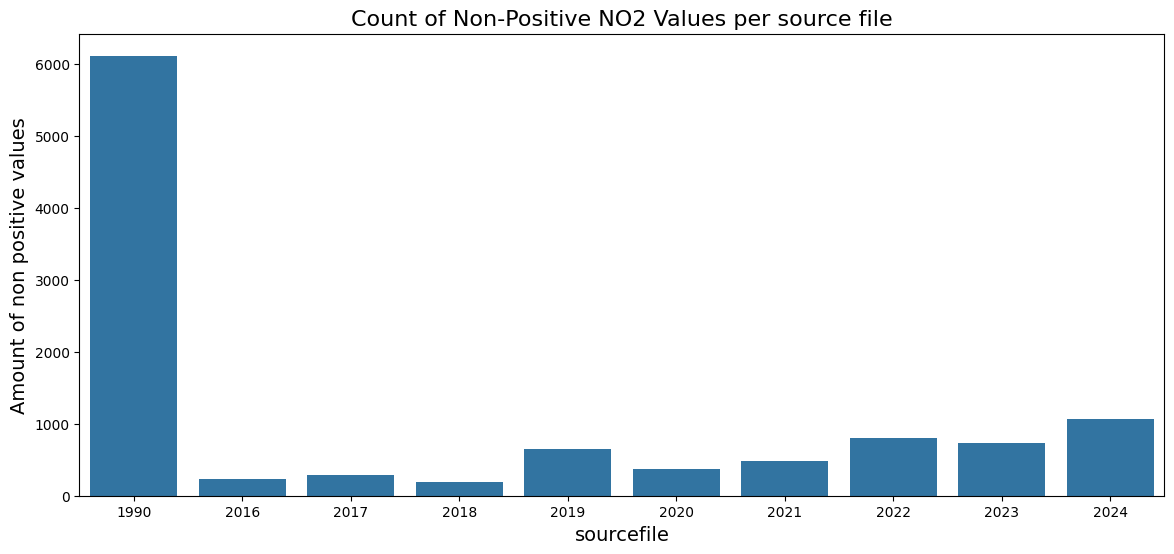

In [ ]:
import seaborn as sns

non_positive_df = main_df[main_df['waarde'] <= 0]

if non_positive_df.empty:
    print("No non positive values found. Bar chart cannot be created.")
else:
    # extract year from 'begindatumtijd' column
    nonpositive_years = non_positive_df['begindatumtijd'].dt.year

    # count errors per year
    fouten_per_jaar = nonpositive_years.value_counts()
    
    #make a dataframe for seaborn
    plot_df = fouten_per_jaar.reset_index(name='non positive values')
    plot_df.columns = ['year', 'non positive values']
    
    plt.figure(figsize=(14, 6))
    sns.barplot(
        x='year', 
        y='non positive values', 
        data=plot_df)
    plt.title('Count of Non-Positive NO2 Values per source file', fontsize=16)
    plt.xlabel('sourcefile', fontsize=14)
    plt.ylabel('Amount of non positive values', fontsize=14)
    plt.show()

# Cleaning Requirement: All values ≤0 must be imputed to positive values using fillna.
We used the fillna method to fill in the NAN values. This method locates every NAN value in the dataset and fills this instance with the previous instance from the same meetreeks_id. We used this method because the number of instances with NO2 values below or equal to 0 were a small amount in comparison to the total instances. 

The reason for this method is due to the fact that this datasource is a timeseries.

![image.png](attachment:image.png)




In [30]:
import numpy as np 
import pandas as pd 

count_non_positive = (main_df['waarde'] <= 0).sum()
print(f"Count of non positive values: {count_non_positive}")

if count_non_positive > 0: 
    #Assign NaN to non positive values
    initial_total_nans = main_df['waarde'].isnull().sum()
    main_df.loc[main_df['waarde'] <= 0, 'waarde'] = np.nan 

    #impute the NAN values with positive values from the previous record with the same meetreeks_id
    main_df['waarde'] = main_df.groupby('meetreeks_id')['waarde'].fillna(method='ffill')
    
print(f"Final NaN values in 'waarde': {main_df['waarde'].isnull().sum()}") 

Count of non positive values: 10908


C:\Users\enock\AppData\Local\Temp\ipykernel_31268\2166821466.py:13: FutureWarning: SeriesGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use Series.fillna instead
  main_df['waarde'] = main_df.groupby('meetreeks_id')['waarde'].fillna(method='ffill')
C:\Users\enock\AppData\Local\Temp\ipykernel_31268\2166821466.py:13: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  main_df['waarde'] = main_df.groupby('meetreeks_id')['waarde'].fillna(method='ffill')


Final NaN values in 'waarde': 0


## Data transformation


Add province

In [32]:
NO2_pvencoding = NO2_pvencoding = meetlocatie_provincie = {
    'NL01483': 'Zuid-Holland',
    'NL01485': 'Zuid-Holland',
    'NL01486': 'Zuid-Holland',
    'NL01487': 'Zuid-Holland',
    'NL01488': 'Zuid-Holland',
    'NL01489': 'Zuid-Holland',
    'NL01491': 'Zuid-Holland',
    'NL01493': 'Zuid-Holland',
    'NL01494': 'Zuid-Holland',
    'NL01495': 'Zuid-Holland',
    'NL01496': 'Zuid-Holland',
    'NL01497': 'Zuid-Holland',
    'NL01908': 'Zuid-Holland',
    'NL01912': 'Zuid-Holland',
    'NL01913': 'Zuid-Holland',
    'NL10107': 'Limburg',
    'NL10131': 'Limburg',
    'NL10133': 'Limburg',
    'NL10136': 'Limburg',
    'NL10138': 'Limburg',
    'NL10227': 'Noord-Brabant',
    'NL10230': 'Noord-Brabant',
    'NL10235': 'Noord-Brabant',
    'NL10236': 'Noord-Brabant',
    'NL10237': 'Noord-Brabant',
    'NL10238': 'Noord-Brabant',
    'NL10240': 'Noord-Brabant',
    'NL10241': 'Noord-Brabant',
    'NL10246': 'Noord-Brabant',
    'NL10247': 'Noord-Brabant',
    'NL10248': 'Noord-Brabant',
    'NL10301': 'Zeeland',
    'NL10318': 'Zeeland',
    'NL10404': 'Zuid-Holland',
    'NL10418': 'Zuid-Holland',
    'NL10433': 'Zuid-Holland',
    'NL10435': 'Zuid-Holland',
    'NL10437': 'Zuid-Holland',
    'NL10441': 'Zuid-Holland',
    'NL10442': 'Zuid-Holland',
    'NL10444': 'Zuid-Holland',
    'NL10445': 'Zuid-Holland',
    'NL10446': 'Zuid-Holland',
    'NL10449': 'Zuid-Holland',
    'NL10450': 'Zuid-Holland',
    'NL10513': 'Noord-Holland',
    'NL10520': 'Noord-Holland',
    'NL10537': 'Noord-Holland',
    'NL10538': 'Noord-Holland',
    'NL10540': 'Noord-Holland',
    'NL10547': 'Noord-Holland',
    'NL10549': 'Noord-Holland',
    'NL10550': 'Noord-Holland',
    'NL10617': 'Flevoland',
    'NL10620': 'Utrecht',
    'NL10631': 'Flevoland',
    'NL10633': 'Utrecht',
    'NL10636': 'Utrecht',
    'NL10637': 'Utrecht',
    'NL10638': 'Utrecht',
    'NL10639': 'Utrecht',
    'NL10640': 'Utrecht',
    'NL10641': 'Utrecht',
    'NL10643': 'Utrecht',
    'NL10644': 'Utrecht',
    'NL10704': 'Gelderland',
    'NL10720': 'Gelderland',
    'NL10722': 'Gelderland',
    'NL10724': 'Gelderland',
    'NL10727': 'Gelderland',
    'NL10728': 'Gelderland',
    'NL10729': 'Gelderland',
    'NL10738': 'Gelderland',
    'NL10741': 'Gelderland',
    'NL10742': 'Gelderland',
    'NL10807': 'Overijssel',
    'NL10818': 'Overijssel',
    'NL10903': 'Groningen',
    'NL10918': 'Friesland',
    'NL10928': 'Drenthe',
    'NL10929': 'Drenthe',
    'NL10934': 'Friesland',
    'NL10937': 'Groningen',
    'NL10938': 'Groningen',
    'NL49002': 'Noord-Holland',
    'NL49003': 'Noord-Holland',
    'NL49007': 'Noord-Holland',
    'NL49012': 'Noord-Holland',
    'NL49014': 'Noord-Holland',
    'NL49017': 'Noord-Holland',
    'NL49019': 'Noord-Holland',
    'NL49020': 'Noord-Holland',
    'NL49021': 'Noord-Holland',
    'NL49022': 'Noord-Holland',
    'NL49546': 'Noord-Holland',
    'NL49551': 'Noord-Holland',
    'NL49553': 'Noord-Holland',
    'NL49561': 'Noord-Holland',
    'NL49564': 'Noord-Holland',
    'NL49565': 'Noord-Holland',
    'NL49680': 'Flevoland',
    'NL49701': 'Noord-Holland',
    'NL49703': 'Noord-Holland',
    'NL49704': 'Noord-Holland',
    'NL50002': 'Limburg',
    'NL50003': 'Limburg',
    'NL50004': 'Limburg',
    'NL50010': 'Limburg',
    'NL53001': 'Noord-Brabant',
    'NL53004': 'Noord-Brabant',
    'NL53015': 'Noord-Brabant',
    'NL53016': 'Noord-Brabant',
    'NL53020': 'Noord-Brabant',
    'NL54004': 'Gelderland'
}

# match province to meetlocatie_id
main_df['province'] = main_df['meetlocatie_id'].map(NO2_pvencoding)

# Select columns of df
dfno2 = main_df[['province', 'waarde', 'meetlocatie_id']]
print(dfno2.head(10))


  province  waarde meetlocatie_id
0  Limburg    34.0        NL10107
1  Limburg    32.0        NL10107
2  Limburg    34.0        NL10107
3  Limburg    33.0        NL10107
4  Limburg    52.0        NL10107
5  Limburg    63.0        NL10107
6  Limburg    46.0        NL10107
7  Limburg    56.0        NL10107
8  Limburg    51.0        NL10107
9  Limburg    51.0        NL10107


make a df with monthly average values, province and year_month

In [33]:
# Convert date columns to datetime format
#main_df['begindatumtijd'] = pd.to_datetime(main_df['begindatumtijd'])

# Add a new column for year and month 
#main_df['Jaar_Maand'] = main_df['begindatumtijd'].dt.to_period('M')

# Group by the new column and calculate the mean of 'waarde'
#dfno2 = main_df.groupby(['Jaar_Maand','province'])['waarde'].mean().reset_index()

# Rename columns 
#dfno2.columns = ['Year_Month', 'province', 'Average NO2 Value']

# Format the columns
#dfno2['Year_Month'] = dfno2['Year_Month'].astype(str)
#print(dfno2.columns)
#Convert date column to datetime
main_df['begindatumtijd'] = pd.to_datetime(main_df['begindatumtijd'])

#Extract the year from the datetime column
main_df['Jaar'] = main_df['begindatumtijd'].dt.year

#Group by year and province, then calculate the mean NO₂ value
dfno2 = (
    main_df.groupby(['Jaar', 'province'])['waarde']
    .mean()
    .reset_index()
)

#Rename columns
dfno2.columns = ['Year', 'province', 'Average NO2 Value']

#Correct data type for 'Year' column
dfno2['Year'] = dfno2['Year'].astype(int)

#Display the first few rows
print(dfno2.head())


   Year    province  Average NO2 Value
0  1990     Drenthe          18.793554
1  1990   Flevoland          21.913064
2  1990   Friesland          16.636041
3  1990  Gelderland          38.837778
4  1990   Groningen          20.220319


In [6]:
dfno2['Average NO2 Value'].skew()

np.float64(1.2519370804540433)

## Delete 1990 data

In [34]:
dfno2 = dfno2[dfno2['Year'] != 1990]

# then do log / standardize again

print(f"Dataset shape after removing 1990 data: {dfno2.shape}")   

Dataset shape after removing 1990 data: (108, 3)


**log transformation**

In [33]:
a = dfno2['Average NO2 Value']
c = abs(a.min())

In [34]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt



shift = a + c + 0.001
log_x = np.log(shift)  
print(log_x)


12     2.787705
13     2.946701
14     2.738518
15     3.373568
16     3.236737
         ...   
115    3.163210
116    2.542268
117    2.970302
118    2.725108
119    3.224616
Name: Average NO2 Value, Length: 108, dtype: float64


In [35]:
log_x.skew()


np.float64(-0.013301064071221502)

In [11]:
print(dfno2['Average NO2 Value'].head())

12    10.729172
13    13.528489
14     9.949526
15    23.667931
16    19.936011
Name: Average NO2 Value, dtype: float64


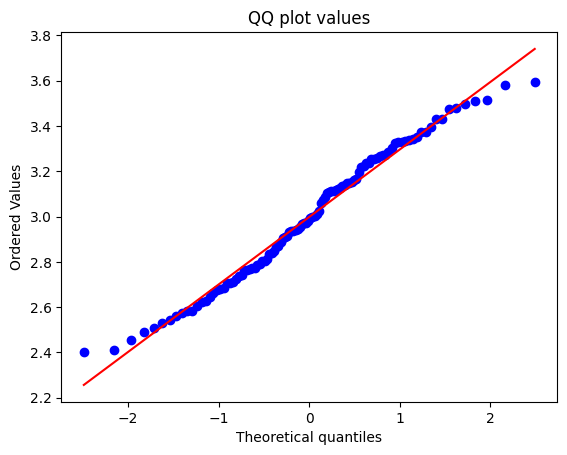

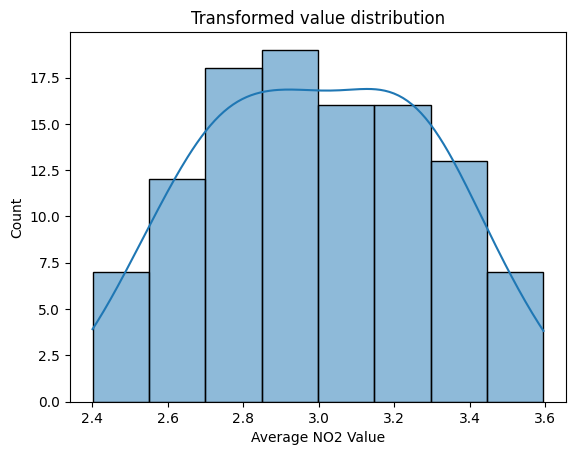

In [36]:
import seaborn as sns 

stats.probplot(log_x, dist="norm", plot=plt)
plt.title("QQ plot values")
plt.show()

sns.histplot(log_x,kde=True)
plt.title("Transformed value distribution")
plt.show()

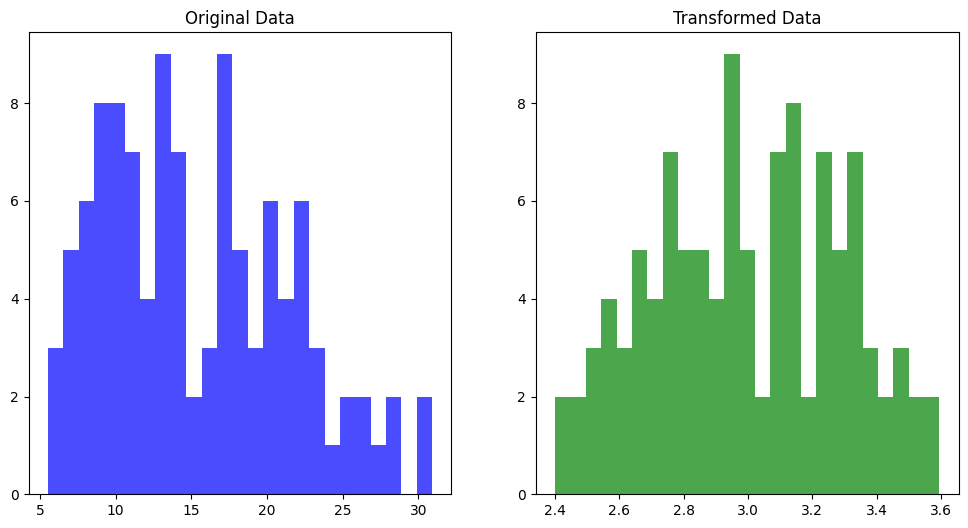

In [14]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(a, bins=25, color='blue', alpha=0.7)
plt.title('Original Data')

plt.subplot(1, 2, 2)
plt.hist(log_x, bins=25, color='green', alpha=0.7)
plt.title('Transformed Data')

plt.show()

In [15]:
%pip install scikit-learn
from sklearn.preprocessing import StandardScaler


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\enock\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## Standardization. negative = below average standardized NO₂
**Since the log_x values are stored as series instead of dataframe, we need to reshape the data. Since we mainly want to use numerical data for the prediction part we scale them so that they will have the same impact on the clustering algorithms (which are sensitive to different data scales). Moreover, it is less sensitive to outliers (compared to minmax() scaling), helping us reduce the impact of these outliers.**
- https://stackoverflow.com/questions/35723472/how-to-use-sklearn-fit-transform-with-pandas-and-return-dataframe-instead-of-num

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Standardize the log-transformed NO₂ values
standardizeNO2 = StandardScaler().fit_transform(log_x.values.reshape(-1, 1))

# Build a  DataFrame instead of a Series
dfstandardizationNO2 = pd.DataFrame({
    'Year': dfno2['Year'].values,
    'province': dfno2['province'].values,
    'Standardized_NO2': standardizeNO2.flatten()
})

# result
print(dfstandardizationNO2.head())
print(f"Skewness of standardized NO₂:", dfstandardizationNO2['Standardized_NO2'].skew())


   Year    province  Standardized_NO2
0  2016     Drenthe         -0.714859
1  2016   Flevoland         -0.174748
2  2016   Friesland         -0.881948
3  2016  Gelderland          1.275331
4  2016   Groningen          0.810513

Skewness of standardized NO₂: -0.01330106407122642


## Linear regression 

Year_month should be correlated with average no2 value. You should see a negative correlation. The average value decreases as time goes on.

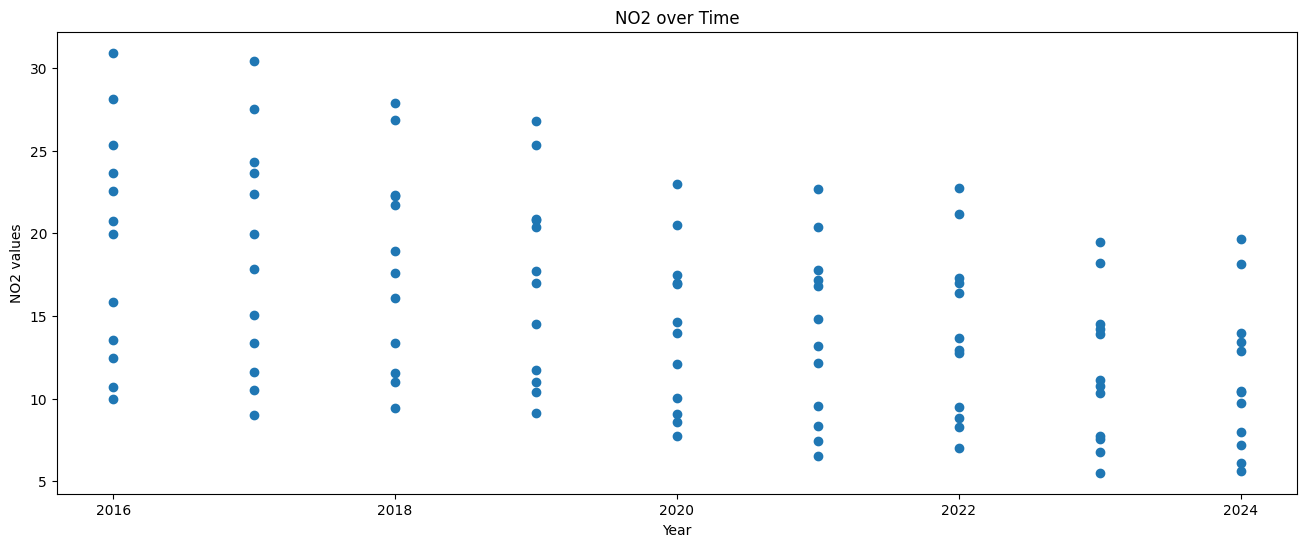

In [ ]:
import matplotlib.pyplot as plt

dfno2['Year'] = dfno2['Year'].astype(int)

plt.figure(figsize=(16, 6))
plt.scatter(
    dfno2['Year'],
    dfno2['Average NO2 Value']
)

plt.title("NO2 over Time")
plt.xlabel("Year")
plt.ylabel("NO2 values")

years = sorted(dfno2['Year'].unique())

plt.show()


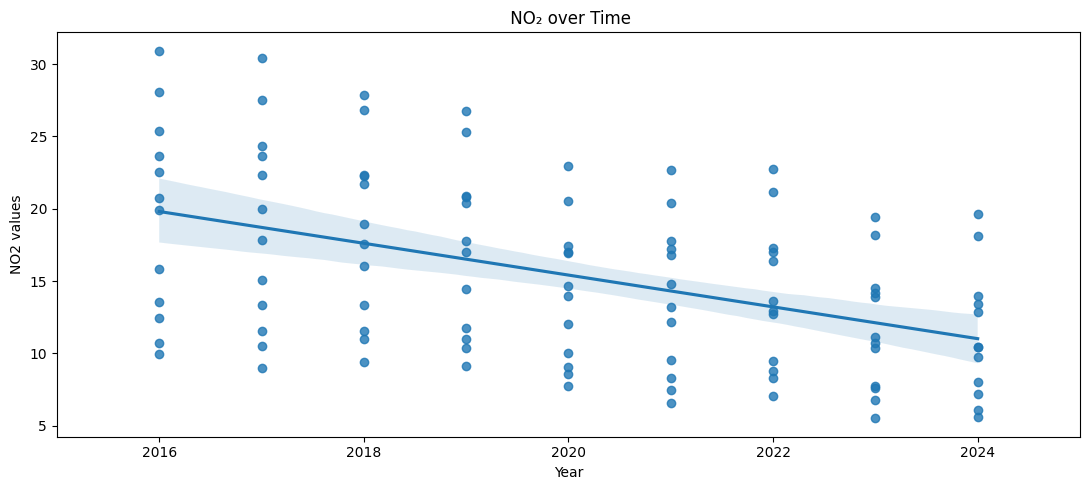

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot
plt.figure(figsize=(11, 5))
ax = plt.gca()

sns.regplot(
    x='Year',
    y='Average NO2 Value',
    data=dfno2,
    ax=ax
)

# Labels and formatting
ax.set_title(" NO₂ over Time")
ax.set_xlabel("Year")
ax.set_ylabel("NO2 values")

years = sorted(dfno2['Year'].unique())

plt.xlim(2015, 2025) 

plt.show()


In [52]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd

df_yearly = (
    dfno2
    .groupby(['Year', 'province'], as_index=False)['Average NO2 Value']
    .mean()
    .dropna()
)

# features and target
X = df_yearly[['Year', 'province']]
y = df_yearly['Average NO2 Value']  #raw value target 

# necessary if “province” is uncluded as a predictor in model. Because scikit can't handle string data
preprocessor = ColumnTransformer(
    transformers=[
        ('province', OneHotEncoder(drop='first'), ['province'])
    ],
    remainder='passthrough'   # keeps Year
)

# pipeline
model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('regressor', LinearRegression())
])

In [38]:
import pandas as pd

# Load the monthly predictions
monthly = pd.read_csv('predicted_NO2values_monthly_2025_2031.csv')

# Extract the year from Year_Month
monthly['Year'] = monthly['Year_Month'].str[:4].astype(int)

# Group by year and province, then take the mean
yearly = (
    monthly.groupby(['Year', 'province'], as_index=False)['predicted_NO2']
    .mean()
    .rename(columns={'predicted_NO2': 'Average_predicted_NO2'})
)

# Round the predicted values to integers
yearly['Average_predicted_NO2'] = yearly['Average_predicted_NO2'].round(0).astype('Int64')

# Save the result
yearly.to_csv('predicted_NO2values_yearly_2025_2031.csv', index=False)

print("Saved: predicted_NO2values_yearly_2025_2031.csv")
print(yearly.head(12))

Saved: predicted_NO2values_yearly_2025_2031.csv
    Year       province  Average_predicted_NO2
0   2025        Drenthe                      5
1   2025      Flevoland                      8
2   2025      Friesland                      4
3   2025     Gelderland                     17
4   2025      Groningen                     11
5   2025        Limburg                     13
6   2025  Noord-Brabant                     16
7   2025  Noord-Holland                     20
8   2025     Overijssel                      7
9   2025        Utrecht                     17
10  2025        Zeeland                     10
11  2025   Zuid-Holland                     22


#### Validation of the regression model with Time series validation
https://www.w3schools.com/python/python_ml_cross_validation.asp

In [51]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

#  Use Time Series Cross-Validation for evaluation
tscv = TimeSeriesSplit(n_splits=10)

# Evaluate the model with R2 
scores_yearly = cross_val_score(model, X, y, cv=tscv, scoring='r2')

# results
print("Yearly R2 per fold:", scores_yearly)
print("Mean Yearly R2:", scores_yearly.mean())
print("Number of folds used:", len(scores_yearly))

Yearly R2 per fold: [0.99100081 0.9399331  0.97180122 0.88384371 0.82400558 0.93083976
 0.85923261 0.91805147 0.85477285 0.9055429 ]
Mean Yearly R2: 0.9079024008256953
Number of folds used: 10


In [ ]:
import matplotlib.pyplot as plt  
import numpy as np

# Fit model 
model.fit(X, y)

# Make predictions
y_pred = model.predict(X)

# Calculate MSE
MSE = np.square(y - y_pred).mean()

# Calculate Root Mean Squared Error 
RMSE = np.sqrt(MSE)

print(f"Mean Squared Error (MSE): {MSE}")
print(f"Root Mean Squared Error (RMSE): {RMSE}")

Mean Squared Error (MSE): 1.3925951572018629
Root Mean Squared Error (RMSE): 1.1800826908322413


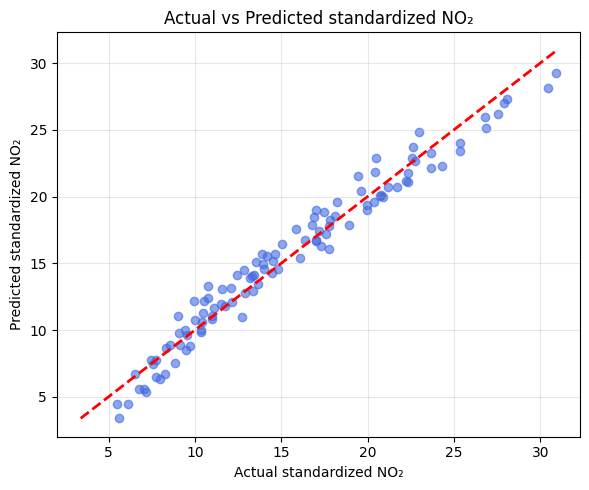

In [ ]:
import matplotlib.pyplot as plt

# Fit model and predict
model.fit(X, y)
y_pred = model.predict(X)

# Determine limits
min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())

# Plot
plt.figure(figsize=(6, 5))
plt.scatter(y, y_pred, alpha=0.6, color='royalblue')

# Add red prediction line 
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Actual NO2")
plt.ylabel("Predicted NO2")
plt.title("Actual vs Predicted NO2")
plt.grid(alpha=0.3)
plt.show()